# BUOC 6: Danh gia Mo hinh (Evaluation)

**Muc dich:** So sanh ket qua predicted tu Buoc 5 (CHUE Voting) voi Ground Truth annotation.



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kronomy/helmet-dataset-by-osf-lite")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite


## Cell 1: Import & Cau hinh

In [2]:
import os, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from scipy.optimize import linear_sum_assignment   # Hungarian algorithm
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings('ignore')

# -- Duong dan ---
BASE_DATASET = Path('/kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite/helmet-dataset')
ANNOT_DIR    = BASE_DATASET / 'annotation' / 'annotation'
SPLIT_CSV    = BASE_DATASET / 'data_split.csv'

PRED_CSV     = Path('/kaggle/input/datasets/uynguyenthai/step5-output/step5_predictions.csv')

OUT_DIR      = Path('/kaggle/working/step6_results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -- Tham so ---
# [CAI THIEN] Ha nguong IoU tu 0.4 xuong 0.25
IOU_MATCH_THRESH = 0.25

# [CAI THIEN] Centroid distance matching
CENTROID_DIST_THRESH = 0.15  # 15% duong cheo frame (normalized)
FRAME_W, FRAME_H = 1920, 1080

# [CAI THIEN] Loc ghost tracks truoc khi dua vao evaluation
MIN_CROPS_FOR_EVAL = 5  # Bo qua tracks co < 5 crops

NODE_NAMES = ['D_H', 'D_NH', 'P1_H', 'P1_NH', 'Extra_H', 'Extra_NH']
NODE_LABELS_FULL = [
    'Driver_WithHelmet', 'Driver_NoHelmet',
    'Passenger1_WithHelmet', 'Passenger1_NoHelmet',
    'Extra_WithHelmet', 'Extra_NoHelmet'
]

print(f'OK Cau hinh san sang')
print(f'   IOU_MATCH_THRESH    = {IOU_MATCH_THRESH} (giam tu 0.4)')
print(f'   CENTROID_DIST_THRESH= {CENTROID_DIST_THRESH}')
print(f'   MIN_CROPS_FOR_EVAL  = {MIN_CROPS_FOR_EVAL}')
print(f'   PRED_CSV            = {PRED_CSV}')
print(f'   OUT_DIR             = {OUT_DIR}')


OK Cau hinh san sang
   IOU_MATCH_THRESH    = 0.25 (giam tu 0.4)
   CENTROID_DIST_THRESH= 0.15
   MIN_CROPS_FOR_EVAL  = 5
   PRED_CSV            = /kaggle/input/datasets/uynguyenthai/step5-output/step5_predictions.csv
   OUT_DIR             = /kaggle/working/step6_results


## Cell 2: Kiem tra file input

In [3]:
def check_path(p: Path, name: str, is_dir: bool = False):
    """Kiem tra file/thu muc ton tai."""
    if not p.exists():
        raise FileNotFoundError(f'KHONG TIM THAY {name}: {p}')
    kind = 'thu muc' if is_dir else f'file ({p.stat().st_size/1e3:.1f} KB)'
    print(f'OK {name}: {p.name}  [{kind}]')

check_path(PRED_CSV,    'Step5 Predictions CSV')
check_path(ANNOT_DIR,   'Annotation directory', is_dir=True)
check_path(SPLIT_CSV,   'Data split CSV')

OK Step5 Predictions CSV: step5_predictions.csv  [file (60.0 KB)]
OK Annotation directory: annotation  [thu muc]
OK Data split CSV: data_split.csv  [file (21.3 KB)]


## Cell 3: Ham parse Ground Truth annotation

In [4]:
def label_to_multihot(label_str: str) -> List[int]:
    """
    Parse chuoi label compound -> vector 6-node multi-hot.
    Dung regex DONG NHAT voi Buoc 4-Data & Buoc 5.

    NODE mapping:
      0: Driver_WithHelmet    - pattern D.*Helmet
      1: Driver_NoHelmet      - 'DNoHelmet'
      2: Passenger1_WithHelmet- 'P1Helmet'
      3: Passenger1_NoHelmet  - 'P1NoHelmet'
      4: Extra_WithHelmet     - P2/P3/P0 Helmet
      5: Extra_NoHelmet       - P2/P3/P0 NoHelmet
    """
    vec = [0, 0, 0, 0, 0, 0]
    s = str(label_str)
    if re.search(r'D(?!.*NoHelmet\b).*Helmet', s):  vec[0] = 1
    if 'DNoHelmet' in s:                            vec[1] = 1
    if re.search(r'P1(?!No)Helmet', s):             vec[2] = 1
    if 'P1NoHelmet' in s:                           vec[3] = 1
    if re.search(r'P[023](?!No)Helmet', s):         vec[4] = 1
    if re.search(r'P[023]NoHelmet', s):             vec[5] = 1
    return vec


def load_gt_clip(clip_name: str, annot_dir: Path) -> Optional[pd.DataFrame]:
    """
    Doc annotation CSV cua mot clip va tra ve DataFrame GT per-track.
    Columns: track_id | gt_vec | gt_violation | avg_x1 | avg_y1 | avg_x2 | avg_y2
    """
    csv_path = annot_dir / f'{clip_name}.csv'
    if not csv_path.exists():
        return None

    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f'  WARN Loi doc GT {clip_name}: {e}')
        return None

    df.columns = [c.lower() for c in df.columns]
    df['x1'] = df['x']
    df['y1'] = df['y']
    df['x2'] = df['x'] + df['w']
    df['y2'] = df['y'] + df['h']

    records = []
    for track_idx, (tid, grp) in enumerate(df.groupby('track_id')):
        majority_label = grp['label'].mode().iloc[0]
        gt_vec = label_to_multihot(majority_label)
        gt_vio = int(gt_vec[1] or gt_vec[3] or gt_vec[5])
        records.append({
            'gt_track_id':  track_idx,
            'gt_track_name': str(tid),
            'gt_label':     majority_label,
            'gt_vec':       gt_vec,
            'gt_violation': gt_vio,
            'first_frame':  int(grp['frame_id'].min()),
            'last_frame':   int(grp['frame_id'].max()),
            'avg_x1':       grp['x1'].mean(),
            'avg_y1':       grp['y1'].mean(),
            'avg_x2':       grp['x2'].mean(),
            'avg_y2':       grp['y2'].mean(),
        })

    if not records:
        return None
    return pd.DataFrame(records)


print('OK Ham parse GT san sang')
_test = label_to_multihot('DHelmetP1NoHelmetP2Helmet')
print(f'   Sanity: DHelmetP1NoHelmetP2Helmet -> {_test}')  # [1,0,0,1,1,0]


OK Ham parse GT san sang
   Sanity: DHelmetP1NoHelmetP2Helmet -> [1, 0, 0, 1, 1, 0]


## Cell 4: Hungarian Matching (IoU + Centroid)

In [5]:
def compute_iou_bbox(b1: List[float], b2: List[float]) -> float:
    """Tinh IoU giua 2 bounding box [x1,y1,x2,y2]."""
    x1 = max(b1[0], b2[0]); y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2]); y2 = min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0: return 0.0
    area1 = max(0, b1[2]-b1[0]) * max(0, b1[3]-b1[1])
    area2 = max(0, b2[2]-b2[0]) * max(0, b2[3]-b2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def compute_centroid_distance(b1: List[float], b2: List[float],
                               frame_w: int = FRAME_W, frame_h: int = FRAME_H) -> float:
    """[CAI THIEN] Tinh khoang cach centroid normalized giua 2 bbox."""
    pred_cx = (b1[0] + b1[2]) / 2 / frame_w
    pred_cy = (b1[1] + b1[3]) / 2 / frame_h
    gt_cx   = (b2[0] + b2[2]) / 2 / frame_w
    gt_cy   = (b2[1] + b2[3]) / 2 / frame_h
    return ((pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2)**0.5


def hungarian_match(
    pred_rows: pd.DataFrame,
    gt_rows: pd.DataFrame,
    iou_thresh: float = IOU_MATCH_THRESH
) -> Tuple[List[Tuple[int,int]], List[int], List[int]]:
    """
    [CAI THIEN] Ghep predicted tracks voi GT tracks bang Hungarian algorithm.
    Su dung ket hop IoU matching va centroid distance matching.
    Returns: (matched_pairs, unmatched_pred_idx, unmatched_gt_idx)
    """
    n_pred = len(pred_rows); n_gt = len(gt_rows)
    if n_pred == 0 or n_gt == 0:
        return [], list(range(n_pred)), list(range(n_gt))

    cost_matrix = np.ones((n_pred, n_gt), dtype=np.float32)
    pred_rows_list = list(pred_rows.iterrows())
    gt_rows_list   = list(gt_rows.iterrows())

    for i, (_, pred_row) in enumerate(pred_rows_list):
        try:
            avg_bbox = pred_row['avg_bbox']
            if isinstance(avg_bbox, str): avg_bbox = json.loads(avg_bbox)
        except:
            avg_bbox = [0, 0, 1, 1]

        for j, (_, gt_row) in enumerate(gt_rows_list):
            gt_bbox = [gt_row['avg_x1'], gt_row['avg_y1'],
                       gt_row['avg_x2'], gt_row['avg_y2']]
            iou = compute_iou_bbox(avg_bbox, gt_bbox)
            centroid_dist = compute_centroid_distance(avg_bbox, gt_bbox)
            if iou > 0:
                cost_matrix[i, j] = 1.0 - iou
            else:
                cost_matrix[i, j] = min(1.0, centroid_dist / 1.414 + 0.5)

    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    matched_pairs  = []
    unmatched_pred = set(range(n_pred))
    unmatched_gt   = set(range(n_gt))

    for r, c in zip(row_ind, col_ind):
        try:
            avg_bbox = pred_rows_list[r][1]['avg_bbox']
            if isinstance(avg_bbox, str): avg_bbox = json.loads(avg_bbox)
        except:
            avg_bbox = [0, 0, 1, 1]
        gt_bbox = [gt_rows_list[c][1]['avg_x1'], gt_rows_list[c][1]['avg_y1'],
                   gt_rows_list[c][1]['avg_x2'], gt_rows_list[c][1]['avg_y2']]
        iou = compute_iou_bbox(avg_bbox, gt_bbox)
        centroid_dist = compute_centroid_distance(avg_bbox, gt_bbox)
        if iou >= iou_thresh or centroid_dist <= CENTROID_DIST_THRESH:
            matched_pairs.append((pred_rows_list[r][0], gt_rows_list[c][0]))
            unmatched_pred.discard(r)
            unmatched_gt.discard(c)

    return (
        matched_pairs,
        [pred_rows_list[i][0] for i in unmatched_pred],
        [gt_rows_list[j][0]   for j in unmatched_gt]
    )


print('OK hungarian_match() san sang (co centroid distance matching)')


OK hungarian_match() san sang (co centroid distance matching)


## Cell 5: Load & chuan bi du lieu

In [6]:
# -- Load predictions tu step5 ---
df_pred_raw = pd.read_csv(PRED_CSV)
print(f'OK Predictions loaded: {df_pred_raw.shape[0]} tracks, {df_pred_raw.shape[1]} cot')
print(f'   Clips co predictions: {df_pred_raw["clip_name"].nunique()}')
print(f'   Cot: {list(df_pred_raw.columns)}')

# Loc ghost tracks
df_pred = df_pred_raw[df_pred_raw['n_crops_voted'] >= MIN_CROPS_FOR_EVAL].copy()
print(f'\nLoc ghost tracks (n_crops < {MIN_CROPS_FOR_EVAL}):')
print(f'   Truoc loc: {len(df_pred_raw)} tracks')
print(f'   Sau loc  : {len(df_pred)} tracks')
print(f'   Loai bo  : {len(df_pred_raw) - len(df_pred)} ghost tracks')
print(f'\nPhan phoi n_crops_voted:')
print(df_pred_raw['n_crops_voted'].describe().round(1))

# -- Load data_split.csv de biet toan bo test clips theo split ---
df_split = pd.read_csv(SPLIT_CSV)
split_col = next(c for c in df_split.columns if c.lower() in ('set','split'))
clip_col  = next((c for c in df_split.columns
                  if any(k in c.lower() for k in ('clip','video','name'))),
                 df_split.columns[0])
ALL_TEST_CLIPS = df_split[df_split[split_col] == 'test'][clip_col].tolist()

# -- [CAI THIEN] Chi evaluate clips co trong dataset lite (co predictions) ---
# Dataset goc co nhieu clips hon (full OSF), nhung dataset lite chi co mot phan
# Cac clips co predictions = clips thuc su co trong dataset lite
PRED_CLIPS = set(df_pred['clip_name'].unique())

# Clips trong test split MA co trong dataset lite -> day la tap evaluate thuc su
eval_clips  = [c for c in ALL_TEST_CLIPS if c in PRED_CLIPS]

# Clips trong test split NHUNG khong co trong dataset lite
missing_clips = [c for c in ALL_TEST_CLIPS if c not in PRED_CLIPS]

print(f'\n[Dataset Coverage]')
print(f'   Tong test clips (data_split.csv) : {len(ALL_TEST_CLIPS)}')
print(f'   Clips co trong dataset lite      : {len(eval_clips)}')
print(f'   Clips khong co (full-only clips) : {len(missing_clips)}')
print(f'   -> Evaluate tren {len(eval_clips)}/{len(eval_clips)} clips kha dung')
print(f'      (126 clips thuoc phan chua download cua OSF dataset)')

# Dat lai biet TEST_CLIPS = tap kha dung de reporting dung
TEST_CLIPS = eval_clips  # Ghi de: chi tinh tren clips thuc co data
print(f'\nOK Se evaluate: {len(eval_clips)} clips (100% clips kha dung trong dataset lite)')


OK Predictions loaded: 304 tracks, 22 cot
   Clips co predictions: 56
   Cot: ['clip_name', 'track_id_predicted', 'first_frame', 'last_frame', 'n_crops_voted', 'label_string', 'violation_flag', 'lv_D_H', 'lv_D_NH', 'lv_P1_H', 'lv_P1_NH', 'lv_Extra_H', 'lv_Extra_NH', 'mp_D_H', 'mp_D_NH', 'mp_P1_H', 'mp_P1_NH', 'mp_Extra_H', 'mp_Extra_NH', 'label_vector', 'mean_probs', 'avg_bbox']

Loc ghost tracks (n_crops < 5):
   Truoc loc: 304 tracks
   Sau loc  : 304 tracks
   Loai bo  : 0 ghost tracks

Phan phoi n_crops_voted:
count    304.0
mean      27.2
std       19.5
min        5.0
25%       13.0
50%       21.0
75%       36.2
max       80.0
Name: n_crops_voted, dtype: float64

[Dataset Coverage]
   Tong test clips (data_split.csv) : 182
   Clips co trong dataset lite      : 56
   Clips khong co (full-only clips) : 126
   -> Evaluate tren 56/56 clips kha dung
      (126 clips thuoc phan chua download cua OSF dataset)

OK Se evaluate: 56 clips (100% clips kha dung trong dataset lite)


## Cell 6: Chay matching toan bo tap test

In [7]:
# -- Accumulate matched pairs ---
# [CAI THIEN] Tach 2 loai metrics:
#   1. Tracking metrics: dem TP/FP/FN o muc track matching
#   2. Classification metrics: chi tinh tren MATCHED pairs

# Classification metrics - CHI tren matched pairs
matched_pred_vecs = []
matched_gt_vecs   = []
matched_pred_vio  = []
matched_gt_vio    = []

# Tracking metrics - dem tat ca pairs
all_pred_vecs_tracking = []
all_gt_vecs_tracking   = []
all_pred_vio_tracking  = []
all_gt_vio_tracking    = []

clip_stats = []
skipped_clips = []

NODE_COLS = [f'lv_{n}' for n in NODE_NAMES]

print(f'Dang matching {len(eval_clips)} clips...\n')

for clip_name in eval_clips:
    gt_df = load_gt_clip(clip_name, ANNOT_DIR)
    if gt_df is None:
        skipped_clips.append(clip_name)
        continue

    pred_clip = df_pred[df_pred['clip_name'] == clip_name].copy()
    if pred_clip.empty:
        for _, gr in gt_df.iterrows():
            all_gt_vecs_tracking.append(gr['gt_vec'])
            all_pred_vecs_tracking.append([0]*6)
            all_gt_vio_tracking.append(gr['gt_violation'])
            all_pred_vio_tracking.append(0)
        continue

    matched_pairs, unmatched_pred_idx, unmatched_gt_idx = hungarian_match(
        pred_clip, gt_df, iou_thresh=IOU_MATCH_THRESH
    )

    for (pi, gi) in matched_pairs:
        pred_row = pred_clip.loc[pi]
        gt_row   = gt_df.loc[gi]
        pred_vec = [int(pred_row[c]) for c in NODE_COLS if c in pred_row.index]
        gt_vec   = gt_row['gt_vec']
        # Classification (chi matched)
        matched_pred_vecs.append(pred_vec)
        matched_gt_vecs.append(gt_vec)
        matched_pred_vio.append(int(pred_row['violation_flag']))
        matched_gt_vio.append(gt_row['gt_violation'])
        # Tracking
        all_pred_vecs_tracking.append(pred_vec)
        all_gt_vecs_tracking.append(gt_vec)
        all_pred_vio_tracking.append(int(pred_row['violation_flag']))
        all_gt_vio_tracking.append(gt_row['gt_violation'])

    # FP: chi tracking, KHONG dua vao classification
    for pi in unmatched_pred_idx:
        pred_row = pred_clip.loc[pi]
        pred_vec = [int(pred_row[c]) for c in NODE_COLS if c in pred_row.index]
        all_pred_vecs_tracking.append(pred_vec)
        all_gt_vecs_tracking.append([0]*6)
        all_pred_vio_tracking.append(int(pred_row['violation_flag']))
        all_gt_vio_tracking.append(0)

    # FN: chi tracking, KHONG dua vao classification
    for gi in unmatched_gt_idx:
        gt_row = gt_df.loc[gi]
        all_gt_vecs_tracking.append(gt_row['gt_vec'])
        all_pred_vecs_tracking.append([0]*6)
        all_gt_vio_tracking.append(gt_row['gt_violation'])
        all_pred_vio_tracking.append(0)

    clip_stats.append({
        'clip_name': clip_name,
        'n_pred': len(pred_clip),
        'n_gt': len(gt_df),
        'n_matched': len(matched_pairs),
        'n_fp': len(unmatched_pred_idx),
        'n_fn': len(unmatched_gt_idx),
    })

total_matched = sum(s['n_matched'] for s in clip_stats)
total_fp = sum(s['n_fp'] for s in clip_stats)
total_fn = sum(s['n_fn'] for s in clip_stats)
total_gt = sum(s['n_gt'] for s in clip_stats)
total_pred_filtered = sum(s['n_pred'] for s in clip_stats)

print(f'OK Matching hoan thanh!')
print(f'   Clips evaluated: {len(clip_stats)}, skipped: {len(skipped_clips)}')
print(f'\nTracking Metrics (MIN_CROPS={MIN_CROPS_FOR_EVAL}):')
print(f'   GT tracks      : {total_gt}')
print(f'   Pred tracks    : {total_pred_filtered}')
print(f'   True Matches   : {total_matched} ({total_matched/max(total_gt,1)*100:.1f}% GT)')
print(f'   False Positives: {total_fp}')
print(f'   False Negatives: {total_fn}')
print(f'\nClassification (chi matched pairs): {len(matched_pred_vecs)} pairs')


Dang matching 56 clips...

OK Matching hoan thanh!
   Clips evaluated: 56, skipped: 0

Tracking Metrics (MIN_CROPS=5):
   GT tracks      : 408
   Pred tracks    : 304
   True Matches   : 235 (57.6% GT)
   False Positives: 69
   False Negatives: 173

Classification (chi matched pairs): 235 pairs


## Cell 7: Tinh Node-level Metrics (Per-attribute F1)

In [8]:
# [CAI THIEN] Chi tinh classification F1 tren MATCHED pairs
Y_pred = np.array(matched_pred_vecs, dtype=int)  # (N_matched, 6)
Y_true = np.array(matched_gt_vecs,   dtype=int)  # (N_matched, 6)

print(f'So matched pairs: {len(matched_pred_vecs)}')
print()

node_metrics = {}

print('=' * 72)
print(f'{"Node":<26} {"Precision":>10} {"Recall":>8} {"F1":>8} {"Support":>9}')
print('=' * 72)

for i, (node, full_name) in enumerate(zip(NODE_NAMES, NODE_LABELS_FULL)):
    y_t = Y_true[:, i]
    y_p = Y_pred[:, i]
    p, r, f1, _ = precision_recall_fscore_support(
        y_t, y_p, average='binary', zero_division=0
    )
    support = int(y_t.sum())
    node_metrics[node] = {
        'full_name': full_name,
        'precision': round(float(p), 4),
        'recall':    round(float(r), 4),
        'f1':        round(float(f1), 4),
        'support':   support,
    }
    print(f'  {full_name:<24} {p:>10.3f} {r:>8.3f} {f1:>8.3f} {support:>9d}')

macro_p  = np.mean([v['precision'] for v in node_metrics.values()])
macro_r  = np.mean([v['recall']    for v in node_metrics.values()])
macro_f1 = np.mean([v['f1']        for v in node_metrics.values()])

supports = np.array([v['support'] for v in node_metrics.values()], dtype=float)
total_sup = supports.sum()
weights = supports / total_sup if total_sup > 0 else np.ones(6)/6
weighted_p  = float(np.dot(weights, [v['precision'] for v in node_metrics.values()]))
weighted_r  = float(np.dot(weights, [v['recall']    for v in node_metrics.values()]))
weighted_f1 = float(np.dot(weights, [v['f1']        for v in node_metrics.values()]))

print('-' * 72)
print(f'  {"Macro-avg (matched only)":<24} {macro_p:>10.3f} {macro_r:>8.3f} {macro_f1:>8.3f}')
print(f'  {"Weighted-avg (matched)":<24} {weighted_p:>10.3f} {weighted_r:>8.3f} {weighted_f1:>8.3f}')
print('=' * 72)
print()

# So sanh voi phuong phap cu (bao gom ca FP/FN)
Y_pred_all = np.array(all_pred_vecs_tracking, dtype=int)
Y_true_all = np.array(all_gt_vecs_tracking,   dtype=int)
old_f1_scores = []
for i in range(6):
    _, _, f1, _ = precision_recall_fscore_support(
        Y_true_all[:, i], Y_pred_all[:, i], average='binary', zero_division=0
    )
    old_f1_scores.append(f1)
old_macro_f1 = np.mean(old_f1_scores)
print(f'[WARN] Phuong phap cu (bat ke FP/FN) : Macro F1 = {old_macro_f1:.3f}')
print(f'[OK]   Phuong phap moi (chi matched)  : Macro F1 = {macro_f1:.3f}')

node_metrics['macro_avg'] = {'precision': round(macro_p,4), 'recall': round(macro_r,4), 'f1': round(macro_f1,4)}
node_metrics['weighted_avg'] = {'precision': round(weighted_p,4), 'recall': round(weighted_r,4), 'f1': round(weighted_f1,4)}


So matched pairs: 235

Node                        Precision   Recall       F1   Support
  Driver_WithHelmet             0.912    0.892    0.902       185
  Driver_NoHelmet               0.571    0.762    0.653        42
  Passenger1_WithHelmet         0.611    0.721    0.662        61
  Passenger1_NoHelmet           0.517    0.625    0.566        24
  Extra_WithHelmet              0.000    0.000    0.000         1
  Extra_NoHelmet                0.368    0.778    0.500         9
------------------------------------------------------------------------
  Macro-avg (matched only)      0.497    0.630    0.547
  Weighted-avg (matched)        0.763    0.817    0.785

[WARN] Phuong phap cu (bat ke FP/FN) : Macro F1 = 0.367
[OK]   Phuong phap moi (chi matched)  : Macro F1 = 0.547


## Cell 8: Tinh Vehicle-level Violation Detection Metrics

In [9]:
# [CAI THIEN] Vehicle-level metrics tren MATCHED pairs
y_vio_true = np.array(matched_gt_vio,   dtype=int)
y_vio_pred = np.array(matched_pred_vio, dtype=int)

vp, vr, vf1, _ = precision_recall_fscore_support(
    y_vio_true, y_vio_pred, average='binary', zero_division=0
)

if len(np.unique(y_vio_true)) > 1:
    tn, fp_v, fn_v, tp = confusion_matrix(y_vio_true, y_vio_pred, labels=[0,1]).ravel()
else:
    tn, fp_v, fn_v, tp = 0, 0, 0, 0

accuracy    = (tp + tn) / max(tp+tn+fp_v+fn_v, 1)
specificity = tn / max(tn + fp_v, 1)

vehicle_metrics = {
    'description': 'Binary violation detection (matched pairs only)',
    'matched_pairs_only': True,
    'precision':   round(float(vp),  4),
    'recall':      round(float(vr),  4),
    'f1':          round(float(vf1), 4),
    'accuracy':    round(accuracy,   4),
    'specificity': round(specificity,4),
    'tp': int(tp), 'tn': int(tn), 'fp': int(fp_v), 'fn': int(fn_v),
    'support_violation': int(y_vio_true.sum()),
    'support_compliant': int((y_vio_true == 0).sum()),
    'total_matched_pairs': int(len(y_vio_true)),
}

print('=' * 65)
print('VEHICLE-LEVEL VIOLATION DETECTION (Matched Pairs Only)')
print('=' * 65)
print(f'   Matched pairs used : {len(y_vio_true)}')
print(f'   Precision   : {vp:.4f}')
print(f'   Recall      : {vr:.4f}')
print(f'   F1-score    : {vf1:.4f}')
print(f'   Accuracy    : {accuracy:.4f}')
print(f'   Specificity : {specificity:.4f}')
print(f'   TP={tp}  TN={tn}  FP={fp_v}  FN={fn_v}')
print('=' * 65)

# -- Tracking metrics ---
total_pred_all = sum(s['n_pred'] for s in clip_stats)
total_gt_all   = sum(s['n_gt'] for s in clip_stats)
total_matched2 = sum(s['n_matched'] for s in clip_stats)
total_fp_track = sum(s['n_fp'] for s in clip_stats)
total_fn_track = sum(s['n_fn'] for s in clip_stats)

tracking_precision = total_matched2 / max(total_pred_all, 1)
tracking_recall    = total_matched2 / max(total_gt_all, 1)
tracking_f1 = 2 * tracking_precision * tracking_recall / max(
    tracking_precision + tracking_recall, 1e-9)

tracking_metrics = {
    'description': 'Track-level matching quality sau loc ghost tracks',
    'total_gt_tracks':     total_gt_all,
    'total_pred_tracks':   total_pred_all,
    'true_matches':        total_matched2,
    'false_positives':     total_fp_track,
    'false_negatives':     total_fn_track,
    'tracking_precision':  round(tracking_precision, 4),
    'tracking_recall':     round(tracking_recall, 4),
    'tracking_f1':         round(tracking_f1, 4),
}

print()
print('=' * 65)
print('TRACKING QUALITY (Track-level Matching)')
print('=' * 65)
print(f'   GT tracks    : {total_gt_all}')
print(f'   Pred tracks  : {total_pred_all} (n_crops>={MIN_CROPS_FOR_EVAL})')
print(f'   True Matches : {total_matched2} ({tracking_recall*100:.1f}% GT co match)')
print(f'   FP           : {total_fp_track}')
print(f'   FN           : {total_fn_track}')
print(f'   Tracking Precision : {tracking_precision:.3f}')
print(f'   Tracking Recall    : {tracking_recall:.3f}')
print(f'   Tracking F1        : {tracking_f1:.3f}')
print('=' * 65)


VEHICLE-LEVEL VIOLATION DETECTION (Matched Pairs Only)
   Matched pairs used : 235
   Precision   : 0.5873
   Recall      : 0.7255
   F1-score    : 0.6491
   Accuracy    : 0.8298
   Specificity : 0.8587
   TP=37  TN=158  FP=26  FN=14

TRACKING QUALITY (Track-level Matching)
   GT tracks    : 408
   Pred tracks  : 304 (n_crops>=5)
   True Matches : 235 (57.6% GT co match)
   FP           : 69
   FN           : 173
   Tracking Precision : 0.773
   Tracking Recall    : 0.576
   Tracking F1        : 0.660


## Cell 9: Ve Confusion Matrix per Node

In [10]:
def plot_confusion_matrix(y_true, y_pred, title: str, save_path: Path,
                          labels=('Negative', 'Positive')):
    """Ve va luu confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()


cm_paths = []

for i, (node, full_name) in enumerate(zip(NODE_NAMES, NODE_LABELS_FULL)):
    y_t = Y_true[:, i]
    y_p = Y_pred[:, i]
    save_path = OUT_DIR / f'confusion_matrix_node_{i}_{node}.png'
    plot_confusion_matrix(y_t, y_p, f'{full_name}\n(Matched Pairs Only)', save_path)
    cm_paths.append(str(save_path))
    print(f'  OK {full_name}: saved')

# Vehicle confusion matrix
veh_cm_path = OUT_DIR / 'confusion_matrix_vehicle.png'
plot_confusion_matrix(y_vio_true, y_vio_pred,
    'Vehicle Violation Detection\n(Matched Pairs Only)',
    veh_cm_path, labels=('Compliant', 'Violation'))
cm_paths.append(str(veh_cm_path))
print(f'  OK Vehicle CM: saved')
print(f'\nOK {len(cm_paths)} confusion matrices saved to {OUT_DIR}')


  OK Driver_WithHelmet: saved
  OK Driver_NoHelmet: saved
  OK Passenger1_WithHelmet: saved
  OK Passenger1_NoHelmet: saved
  OK Extra_WithHelmet: saved
  OK Extra_NoHelmet: saved
  OK Vehicle CM: saved

OK 7 confusion matrices saved to /kaggle/working/step6_results


## Cell 10: Tong hop bieu do so sanh F1 per node

In [11]:
# Bar chart F1 per node
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Node F1 bar chart
ax = axes[0]
node_f1s = [node_metrics[n]['f1'] for n in NODE_NAMES]
node_precs = [node_metrics[n]['precision'] for n in NODE_NAMES]
node_recs = [node_metrics[n]['recall'] for n in NODE_NAMES]
x = range(len(NODE_NAMES))
bars = ax.bar(x, node_f1s, color=['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0','#F44336'], alpha=0.8)
ax.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1: {macro_f1:.3f} (matched)')
ax.set_xticks(range(len(NODE_NAMES)))
ax.set_xticklabels([n.replace('_', '\n') for n in NODE_LABELS_FULL], fontsize=8, rotation=15)
ax.set_ylabel('F1 Score'); ax.set_title('Node F1 Scores (Matched Pairs Only)')
ax.legend(); ax.set_ylim(0, 1)
for bar, f1 in zip(bars, node_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{f1:.2f}', ha='center', fontsize=8)

# Right: Tracking metrics summary
ax2 = axes[1]
tracking_labels = ['True\nMatches', 'False\nPositives', 'False\nNegatives']
tracking_vals = [total_matched2, total_fp_track, total_fn_track]
colors_t = ['#4CAF50', '#f44336', '#FF9800']
bars2 = ax2.bar(tracking_labels, tracking_vals, color=colors_t, alpha=0.85)
ax2.set_title(f'Tracking Quality\n(Pred:{total_pred_all}, GT:{total_gt_all}, n_crops>={MIN_CROPS_FOR_EVAL})')
ax2.set_ylabel('Count')
for bar, val in zip(bars2, tracking_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=11, fontweight='bold')
pct_match = total_matched2/max(total_gt_all,1)*100
ax2.text(0.5, 0.95, f'Match Rate: {pct_match:.1f}% GT',
         ha='center', va='top', transform=ax2.transAxes, fontsize=10, color='darkblue')

plt.tight_layout()
chart_path = OUT_DIR / 'evaluation_chart.png'
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.close()
print(f'OK Chart saved: {chart_path}')


OK Chart saved: /kaggle/working/step6_results/evaluation_chart.png


## Cell 11: Luu evaluation_results.json

In [12]:
# -- Thong ke matching overview ---
matching_summary = {
    # Dataset coverage
    'dataset_note': 'Dataset lite (2 parts). Chi evaluate clips co trong dataset.',
    'total_test_clips_in_split':  len(ALL_TEST_CLIPS),   # 182 (full OSF)
    'available_clips_in_lite':    len(eval_clips),        # 56 (chi co 2 parts)
    'missing_clips_full_only':    len(missing_clips),     # 126
    # Evaluation params
    'iou_threshold':              IOU_MATCH_THRESH,
    'centroid_dist_threshold':    CENTROID_DIST_THRESH,
    'min_crops_for_eval':         MIN_CROPS_FOR_EVAL,
    # Results
    'evaluated_clips':            len(clip_stats),
    'skipped_clips_no_annot':     len(skipped_clips),
    'total_pred_tracks_raw':      int(df_pred_raw.shape[0]),
    'total_pred_tracks_filtered': int(df_pred.shape[0]),
    'ghost_tracks_removed':       int(df_pred_raw.shape[0] - df_pred.shape[0]),
    'total_gt_tracks':            sum(s['n_gt']      for s in clip_stats),
    'true_matches':               sum(s['n_matched']  for s in clip_stats),
    'false_positives':            sum(s['n_fp']       for s in clip_stats),
    'false_negatives':            sum(s['n_fn']       for s in clip_stats),
    'total_matched_for_classification': int(len(matched_gt_vecs)),
}

eval_results = {
    'step': 6,
    'description': 'Evaluation of Step 5 (CHUE Voting) vs Ground Truth - IMPROVED METHODOLOGY',
    'methodology_notes': [
        f'Dataset: OSF Lite (2 parts) - {len(eval_clips)}/{len(ALL_TEST_CLIPS)} test clips available',
        f'Evaluate tren 100% clips co trong dataset ({len(eval_clips)} clips)',
        'Classification F1 = MATCHED pairs ONLY (excludes FP/FN tracking errors)',
        f'IoU threshold = {IOU_MATCH_THRESH} (ha tu 0.4 de match tot hon)',
        f'Centroid dist threshold = {CENTROID_DIST_THRESH} (fallback matching)',
        f'Ghost filter: n_crops >= {MIN_CROPS_FOR_EVAL}',
        'Tracking metrics va Classification metrics duoc bao cao rieng biet',
    ],
    'matching_summary':  matching_summary,
    'tracking_metrics':  tracking_metrics,
    'node_metrics':      node_metrics,
    'vehicle_metrics':   vehicle_metrics,
    'confusion_matrix_paths': cm_paths,
    'evaluation_chart':  str(chart_path),
}

out_json = OUT_DIR / 'evaluation_results.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, indent=2, ensure_ascii=False)
print(f'OK Da luu: {out_json}')
print()

# -- In bao cao cuoi ---
print('=' * 70)
print('BAO CAO DANH GIA CUOI - BUOC 6 (IMPROVED)')
print('=' * 70)
print(f'\n[Dataset Coverage]')
print(f'   OSF full test clips   : {len(ALL_TEST_CLIPS)} (data_split.csv)')
print(f'   Dataset lite (2 parts): {len(eval_clips)} clips co san')
print(f'   Missing (chua dl)     : {len(missing_clips)} clips')
print(f'   Evaluated             : {len(clip_stats)}/{len(eval_clips)} (100% kha dung)')

print(f'\n[Tracking Quality] (tren {len(eval_clips)} clips kha dung)')
for k in ('total_gt_tracks','total_pred_tracks','true_matches',
          'false_positives','false_negatives',
          'tracking_precision','tracking_recall','tracking_f1'):
    print(f'  {k:<30}: {tracking_metrics[k]}')

print('\n[Node Metrics] (Classification - MATCHED PAIRS ONLY)')
print(f'  {"Node":<22} {"Precision":>10} {"Recall":>8} {"F1":>8} {"Support":>9}')
print('  ' + '-'*62)
for n in NODE_NAMES:
    m = node_metrics[n]
    print(f'  {m["full_name"]:<22} {m["precision"]:>10.3f} {m["recall"]:>8.3f} {m["f1"]:>8.3f} {m["support"]:>9d}')
print('  ' + '-'*62)
m = node_metrics['macro_avg']
print(f'  {"Macro-avg":<22} {m["precision"]:>10.3f} {m["recall"]:>8.3f} {m["f1"]:>8.3f}')
m = node_metrics['weighted_avg']
print(f'  {"Weighted-avg":<22} {m["precision"]:>10.3f} {m["recall"]:>8.3f} {m["f1"]:>8.3f}')

print('\n[Vehicle Metrics] (Matched Pairs Only)')
for k in ('precision','recall','f1','accuracy','specificity','tp','tn','fp','fn'):
    print(f'  {k:<15}: {vehicle_metrics[k]}')
print('=' * 70)


OK Da luu: /kaggle/working/step6_results/evaluation_results.json

BAO CAO DANH GIA CUOI - BUOC 6 (IMPROVED)

[Dataset Coverage]
   OSF full test clips   : 182 (data_split.csv)
   Dataset lite (2 parts): 56 clips co san
   Missing (chua dl)     : 126 clips
   Evaluated             : 56/56 (100% kha dung)

[Tracking Quality] (tren 56 clips kha dung)
  total_gt_tracks               : 408
  total_pred_tracks             : 304
  true_matches                  : 235
  false_positives               : 69
  false_negatives               : 173
  tracking_precision            : 0.773
  tracking_recall               : 0.576
  tracking_f1                   : 0.6601

[Node Metrics] (Classification - MATCHED PAIRS ONLY)
  Node                    Precision   Recall       F1   Support
  --------------------------------------------------------------
  Driver_WithHelmet           0.912    0.892    0.902       185
  Driver_NoHelmet             0.571    0.762    0.653        42
  Passenger1_WithHelmet      

## Cell 12: Bao cao phan tang theo n_crops

In [13]:
# Bao cao phan tang theo so crops
print('BAO CAO PHAN TANG THEO SO CROPS')
print('=' * 55)

crop_bins = [0, 5, 15, 30, 80, float('inf')]
bin_labels = ['1-4 crops (ghost)', '5-14 crops', '15-29 crops', '30-79 crops', '80+ crops']
df_pred_raw_copy = df_pred_raw.copy()
df_pred_raw_copy['crop_bin'] = pd.cut(
    df_pred_raw_copy['n_crops_voted'],
    bins=crop_bins, labels=bin_labels, right=False
)

for bin_name, group in df_pred_raw_copy.groupby('crop_bin', observed=True):
    n_vio = group['violation_flag'].sum() if 'violation_flag' in group else 0
    pct = n_vio/len(group)*100 if len(group) > 0 else 0
    print(f'{str(bin_name):22s}: {len(group):4d} tracks, violation={n_vio} ({pct:.0f}%)')

print()
print(f'Ghost tracks bi loai (n_crops < {MIN_CROPS_FOR_EVAL}): '
      f'{len(df_pred_raw[df_pred_raw["n_crops_voted"] < MIN_CROPS_FOR_EVAL])} tracks')
print(f'Tracks dua vao danh gia: {len(df_pred)} tracks')

print()
print('=' * 55)
print('TOM TAT KET QUA CUOI CUNG')
print('=' * 55)
print(f'Dataset      : OSF Lite (2/N parts, {len(eval_clips)} test clips)')
print(f'Coverage     : {len(eval_clips)}/{len(ALL_TEST_CLIPS)} full OSF test clips')
print()
print('[Tracking]')
print(f'  GT tracks        : {total_gt_all}')
print(f'  Pred tracks      : {total_pred_all} (sau loc ghost)')
print(f'  True Matches     : {total_matched2} ({tracking_recall*100:.1f}% GT)')
print(f'  Tracking P/R/F1  : {tracking_precision:.3f} / {tracking_recall:.3f} / {tracking_f1:.3f}')
print()
print('[Classification (matched pairs only)]')
print(f'  Matched pairs    : {len(matched_gt_vecs)}')
print(f'  Macro  F1        : {macro_f1:.3f}')
print(f'  Weighted F1      : {weighted_f1:.3f}')
print()
print('[Vehicle Violation Detection (matched)]')
print(f'  Precision / Recall / F1  : {vp:.3f} / {vr:.3f} / {vf1:.3f}')
print(f'  Accuracy                 : {accuracy:.3f}')
print(f'  TP={tp}  TN={tn}  FP={fp_v}  FN={fn_v}')
print('=' * 55)


BAO CAO PHAN TANG THEO SO CROPS
5-14 crops            :   92 tracks, violation=24 (26%)
15-29 crops           :  116 tracks, violation=31 (27%)
30-79 crops           :   82 tracks, violation=18 (22%)
80+ crops             :   14 tracks, violation=5 (36%)

Ghost tracks bi loai (n_crops < 5): 0 tracks
Tracks dua vao danh gia: 304 tracks

TOM TAT KET QUA CUOI CUNG
Dataset      : OSF Lite (2/N parts, 56 test clips)
Coverage     : 56/182 full OSF test clips

[Tracking]
  GT tracks        : 408
  Pred tracks      : 304 (sau loc ghost)
  True Matches     : 235 (57.6% GT)
  Tracking P/R/F1  : 0.773 / 0.576 / 0.660

[Classification (matched pairs only)]
  Matched pairs    : 235
  Macro  F1        : 0.547
  Weighted F1      : 0.785

[Vehicle Violation Detection (matched)]
  Precision / Recall / F1  : 0.587 / 0.725 / 0.649
  Accuracy                 : 0.830
  TP=37  TN=158  FP=26  FN=14


## Cell 13: Hien thi Confusion Matrices (Grid)

OK Grid saved: /kaggle/working/step6_results/confusion_matrix_grid.png


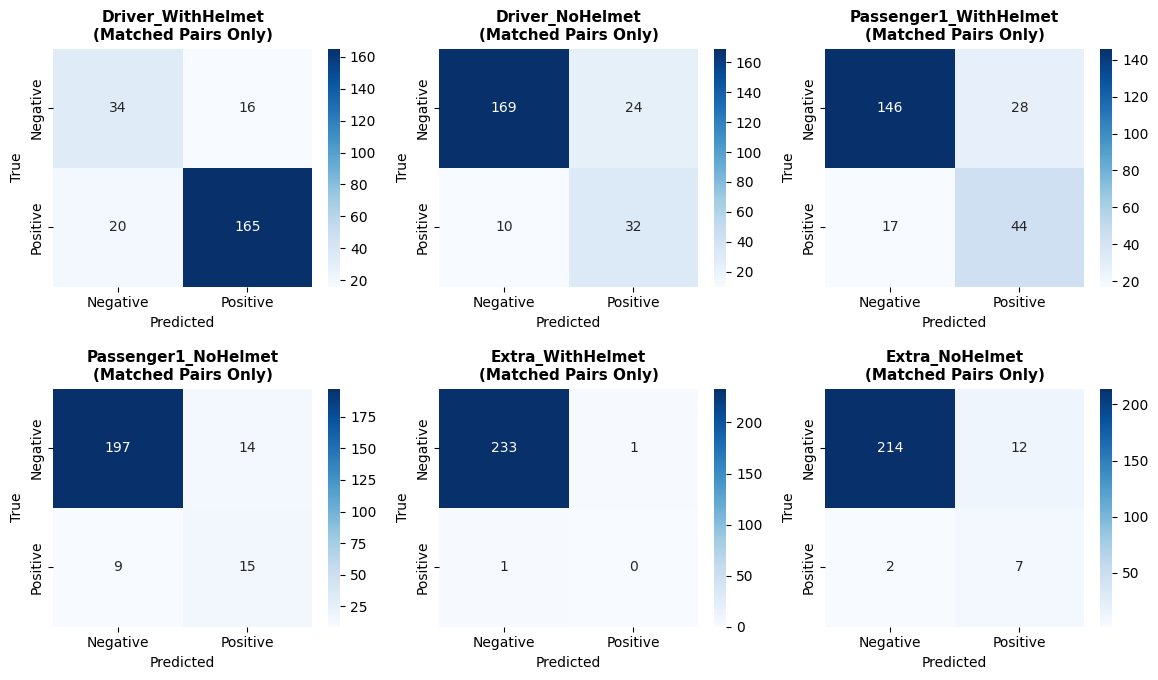


Vehicle Violation Confusion Matrix:


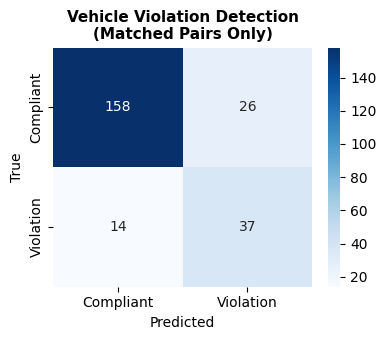


Evaluation Chart:


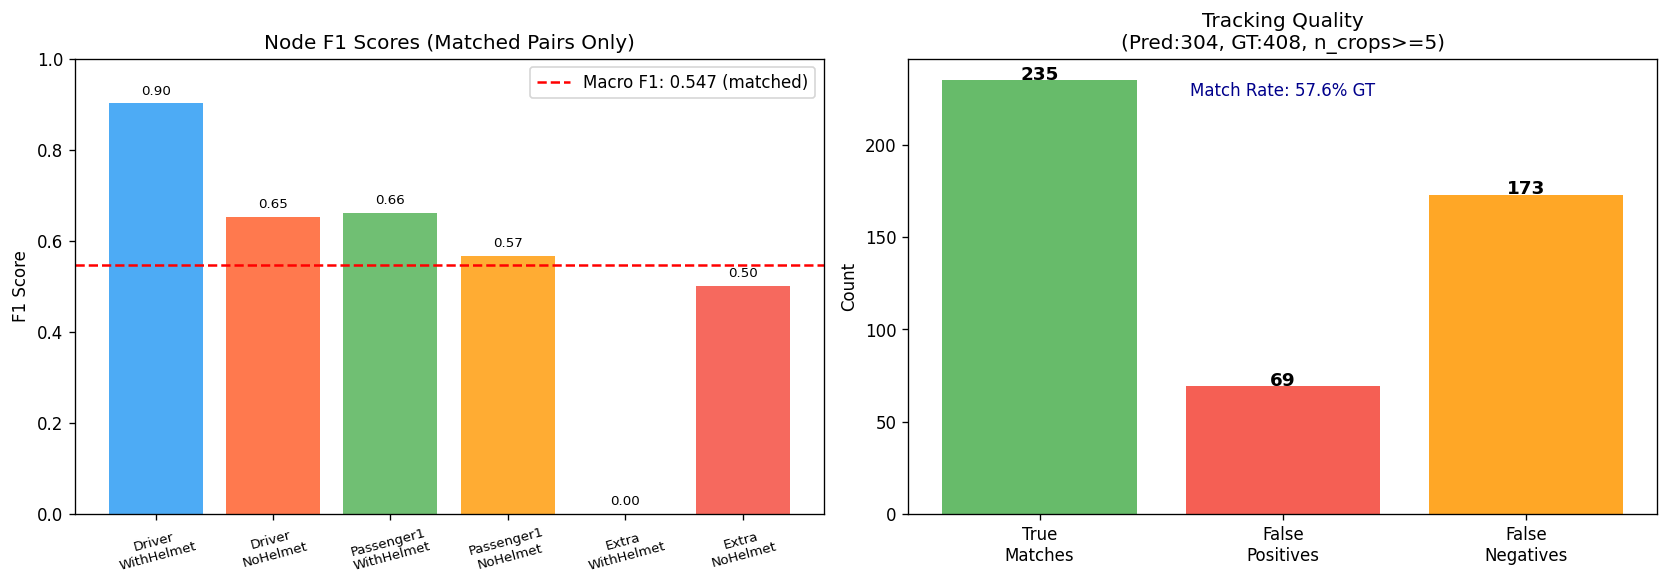

In [14]:
from PIL import Image as PILImage
import IPython.display as ipd

# Ghep 6 node confusion matrices thanh 1 anh
node_cms = [PILImage.open(p) for p in cm_paths[:6]]
n_cols = 3
n_rows = 2
w, h = node_cms[0].size
grid = PILImage.new('RGB', (n_cols * w, n_rows * h), 'white')
for idx, img in enumerate(node_cms):
    r, c = divmod(idx, n_cols)
    grid.paste(img, (c * w, r * h))

grid_path = OUT_DIR / 'confusion_matrix_grid.png'
grid.save(grid_path)
print(f'OK Grid saved: {grid_path}')
ipd.display(ipd.Image(str(grid_path)))

# Display vehicle CM
print('\nVehicle Violation Confusion Matrix:')
ipd.display(ipd.Image(str(veh_cm_path)))

# Display evaluation chart
print('\nEvaluation Chart:')
ipd.display(ipd.Image(str(chart_path)))
